In [ ]:
# ======================================================
# Part 1
# Data Loading & Validation
# ======================================================

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time

import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42

In [2]:
# Read dataset

# DATA_PATH = "../data/processed/energy.parquet"
# df = pd.read_parquet( "block_0.parquet" )

import pandas as pd

df0 = pd.read_parquet("block_0.parquet")
df1 = pd.read_parquet("block_1.parquet")
df2 = pd.read_parquet("block_2.parquet")
df3 = pd.read_parquet("block_3.parquet")
df4 = pd.read_parquet("block_4.parquet")
df5 = pd.read_parquet("block_5.parquet")
df6 = pd.read_parquet("block_6.parquet")
df7 = pd.read_parquet("block_7.parquet")
df8 = pd.read_parquet("block_8.parquet")
df9 = pd.read_parquet("block_9.parquet")
df10 = pd.read_parquet("block_10.parquet")
df11 = pd.read_parquet("block_11.parquet")
df12 = pd.read_parquet("block_12.parquet")
df13 = pd.read_parquet("block_13.parquet")
df14 = pd.read_parquet("block_14.parquet")
df15 = pd.read_parquet("block_15.parquet")
df16 = pd.read_parquet("block_16.parquet")
df17 = pd.read_parquet("block_17.parquet")
df18 = pd.read_parquet("block_18.parquet")
df19 = pd.read_parquet("block_19.parquet")
df20 = pd.read_parquet("block_20.parquet")

df = pd.concat([df0, df1, df2, df3, df4, df5, df6, df7, df8, df9, df10, df11, df12, df13,
               df14, df15, df16, df17, df18, df19, df20], ignore_index=True)

print(df.shape)

print("Dataset Loaded Successfully!")

(31796103, 26)
Dataset Loaded Successfully!


In [3]:
# Satır ve sütun sayısı

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

Rows    : 31,796,103
Columns : 26


In [4]:
# Veri setinin ilk 5 satırı

df.head()

,LCLid,tstp,energy(kWh/hh),stdorToU,Acorn_grouped,price_pence,cost_pounds,visibility,windBearing,temperature,dewPoint,pressure,apparentTemperature,windSpeed,precipType,icon,humidity,summary,lag_1,lag_2,lag_48,lag_336,hour,day_of_week,month,is_weekend
0,MAC000002,2012-10-12 00:30:00,0.0,Std,Affluent,14.228,0.0,12.63,242.0,13.350,11.79,999.785,13.350,6.085,rain,partly-cloudy-night,0.900,Mostly Cloudy,NaN,NaN,NaN,NaN,0,4,10,0
1,MAC000002,2012-10-12 01:00:00,0.0,Std,Affluent,14.228,0.0,13.50,250.0,13.090,11.37,1000.100,13.090,6.770,rain,wind,0.890,Breezy and Mostly Cloudy,0.0,NaN,NaN,NaN,1,4,10,0
2,MAC000002,2012-10-12 01:30:00,0.0,Std,Affluent,14.228,0.0,13.50,251.0,12.815,10.82,1000.305,12.815,6.615,rain,wind,0.875,Breezy and Mostly Cloudy,0.0,0.0,NaN,NaN,1,4,10,0
3,MAC000002,2012-10-12 02:00:00,0.0,Std,Affluent,14.228,0.0,13.50,252.0,12.540,10.27,1000.510,12.540,6.460,rain,partly-cloudy-night,0.860,Mostly Cloudy,0.0,0.0,NaN,NaN,2,4,10,0
4,MAC000002,2012-10-12 02:30:00,0.0,Std,Affluent,14.228,0.0,13.22,251.5,12.240,9.79,1000.620,12.240,6.415,rain,partly-cloudy-night,0.850,Mostly Cloudy,0.0,0.0,NaN,NaN,2,4,10,0


In [5]:
# Veri setinden rastgele 5 satır

df.sample(5)

,LCLid,tstp,energy(kWh/hh),stdorToU,Acorn_grouped,price_pence,cost_pounds,visibility,windBearing,temperature,dewPoint,pressure,apparentTemperature,windSpeed,precipType,icon,humidity,summary,lag_1,lag_2,lag_48,lag_336,hour,day_of_week,month,is_weekend
29844533,MAC005433,2012-12-27 10:00:00,0.021,Std,Affluent,14.228,0.002988,9.770,234.0,7.970,6.710,997.82,5.190,4.660,rain,partly-cloudy-day,0.920,Mostly Cloudy,0.038,0.040,0.031,0.039,10,3,12,0
8719815,MAC000715,2013-09-18 19:30:00,1.318,Std,Affluent,14.228,0.187525,15.215,283.5,12.225,6.590,1009.69,12.225,3.535,rain,partly-cloudy-night,0.685,Mostly Cloudy,1.007,0.954,1.280,0.874,19,2,9,0
27146930,MAC002016,2013-10-14 20:00:00,0.379,Std,Affluent,14.228,0.053924,10.810,248.0,9.230,8.260,1006.75,7.720,2.790,rain,clear-night,0.940,Clear,0.333,0.388,0.911,0.223,20,0,10,0
12181758,MAC002965,2012-07-30 19:30:00,0.363,Std,Affluent,14.228,0.051648,12.460,241.5,16.795,7.535,1015.89,16.795,3.995,rain,partly-cloudy-day,0.545,Partly Cloudy,0.282,0.233,0.320,0.218,19,0,7,0
29472759,MAC002307,2013-06-21 10:00:00,0.067,Std,Affluent,14.228,0.009533,8.930,246.0,16.120,13.830,1009.85,16.120,3.800,rain,cloudy,0.860,Overcast,0.066,0.067,0.057,0.056,10,4,6,0


In [6]:
# Veri setinin genel yapısı

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31796103 entries, 0 to 31796102
Data columns (total 26 columns):
 #   Column               Dtype         
---  ------               -----         
 0   LCLid                object        
 1   tstp                 datetime64[ns]
 2   energy(kWh/hh)       float32       
 3   stdorToU             category      
 4   Acorn_grouped        category      
 5   price_pence          float32       
 6   cost_pounds          float32       
 7   visibility           float64       
 8   windBearing          float64       
 9   temperature          float64       
 10  dewPoint             float64       
 11  pressure             float64       
 12  apparentTemperature  float64       
 13  windSpeed            float64       
 14  precipType           category      
 15  icon                 category      
 16  humidity             float64       
 17  summary              object        
 18  lag_1                float32       
 19  lag_2              

In [7]:
# Tüm sayısal ve kategorik sütunların özet istatistikleri

df.describe(include="all").T

,count,unique,top,freq,first,last,mean,std,min,25%,50%,75%,max
LCLid,31796103,1050,MAC000155,39705,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tstp,31796103,40221,2012-11-16 03:30:00,1043,2011-11-23 13:00:00,2014-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
energy(kWh/hh),31796103.0,NaN,NaN,NaN,NaT,NaT,0.236153,0.346424,0.0,0.068,0.14,0.307,9.71
stdorToU,31796103,2,Std,24798274,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Acorn_grouped,31796103,2,Affluent,31758843,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price_pence,31796103.0,NaN,NaN,NaN,NaT,NaT,9.392929,11.170774,3.99,14.228,14.228,14.228,67.199997
cost_pounds,31796103.0,NaN,NaN,NaN,NaT,NaT,0.037928,0.077564,0.0,0.008537,0.019208,0.04496,5.085024
visibility,31795055.0,NaN,NaN,NaN,NaT,NaT,11.293016,2.960854,0.27,10.37,12.26,13.1,16.09
windBearing,31795055.0,NaN,NaN,NaN,NaT,NaT,194.707868,89.341335,0.0,125.5,215.0,253.5,359.0
temperature,31795055.0,NaN,NaN,NaN,NaT,NaT,10.971907,6.03965,-5.64,6.63,10.545,15.27,32.4


In [8]:
# Veri setindeki her sütunun eksik değer sayısını ve eksik değer yüzdesi

missing = (
    df.isna()
      .sum()
      .to_frame("Missing Values")
)

missing["Percentage"] = (
    missing["Missing Values"] / len(df)
) * 100

missing.sort_values(
    "Missing Values",
    ascending=False
)

,Missing Values,Percentage
lag_336,352509,1.108655
lag_48,50397,0.158501
lag_2,2100,0.006605
lag_1,1050,0.003302
windSpeed,1048,0.003296
pressure,1048,0.003296
humidity,1048,0.003296
icon,1048,0.003296
precipType,1048,0.003296
apparentTemperature,1048,0.003296


In [9]:
# Veri setinde tamamen aynı olan yinelenmiş satırların sayısı

duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


In [10]:
# Target 

target = "energy(kWh/hh)"

print(target)

energy(kWh/hh)


In [11]:
# Modelde kullanılacak olan feature listesi 

feature_columns = [
    c for c in df.columns
    if c not in [
        "energy(kWh/hh)",
        "cost_pounds",
        "LCLid",
        "tstp"
    ]
]

len(feature_columns)

22

In [12]:
feature_columns

['stdorToU',
 'Acorn_grouped',
 'price_pence',
 'visibility',
 'windBearing',
 'temperature',
 'dewPoint',
 'pressure',
 'apparentTemperature',
 'windSpeed',
 'precipType',
 'icon',
 'humidity',
 'summary',
 'lag_1',
 'lag_2',
 'lag_48',
 'lag_336',
 'hour',
 'day_of_week',
 'month',
 'is_weekend']

In [13]:
# ======================================================
# Part 2
# Time-Based Train / Validation / Test Split
# ======================================================

In [13]:
# Önce veriyi zamana göre sıralıyoruz

df = (
    df.sort_values(["tstp", "LCLid"])
      .reset_index(drop=True)
)

# Zaman sınırlarını belirliyoruz
train_end = df["tstp"].quantile(0.70)
validation_end = df["tstp"].quantile(0.85)

print(f"Train end      : {train_end}")
print(f"Validation end : {validation_end}")

Train end      : 2013-08-05 17:00:00
Validation end : 2013-11-14 18:30:00


In [14]:
# Train, validation ve test dataframe’leri

train_df = df[
    df["tstp"] < train_end
].copy()

validation_df = df[
    (df["tstp"] >= train_end) &
    (df["tstp"] < validation_end)
].copy()

test_df = df[
    df["tstp"] >= validation_end
].copy()

print(f"Train rows      : {len(train_df):,}")
print(f"Validation rows : {len(validation_df):,}")
print(f"Test rows       : {len(test_df):,}")

Train rows      : 22,256,924
Validation rows : 4,769,436
Test rows       : 4,769,743


In [15]:
# Tarih aralıklarını doğrulama
# Bütün hanelerde aynı tarih sınırı kullanılmış oldu

split_summary = pd.DataFrame({
    "Dataset": [
        "Train",
        "Validation",
        "Test"
    ],
    "Start": [
        train_df["tstp"].min(),
        validation_df["tstp"].min(),
        test_df["tstp"].min()
    ],
    "End": [
        train_df["tstp"].max(),
        validation_df["tstp"].max(),
        test_df["tstp"].max()
    ],
    "Rows": [
        len(train_df),
        len(validation_df),
        len(test_df)
    ],
    "Households": [
        train_df["LCLid"].nunique(),
        validation_df["LCLid"].nunique(),
        test_df["LCLid"].nunique()
    ]
})

display(split_summary)

,Dataset,Start,End,Rows,Households
0,Train,2011-11-23 13:00:00,2013-08-05 16:30:00,22256924,1048
1,Validation,2013-08-05 17:00:00,2013-11-14 18:00:00,4769436,1004
2,Test,2013-11-14 18:30:00,2014-02-28 00:00:00,4769743,977


In [16]:
# Feature ve target oluşturma

drop_columns = [
    "energy(kWh/hh)",
    "cost_pounds",
    "LCLid",
    "tstp"
]

target_column = "energy(kWh/hh)"

X_train = train_df.drop(columns=drop_columns)
y_train = train_df[target_column]

X_validation = validation_df.drop(columns=drop_columns)
y_validation = validation_df[target_column]

X_test = test_df.drop(columns=drop_columns)
y_test = test_df[target_column]

print("X_train shape      :", X_train.shape)
print("X_validation shape :", X_validation.shape)
print("X_test shape       :", X_test.shape)

X_train shape      : (22256924, 22)
X_validation shape : (4769436, 22)
X_test shape       : (4769743, 22)


In [17]:
# Kategorik sütunlar

categorical_columns = [
    "stdorToU",
    "Acorn_grouped",
    "precipType",
    "icon",
    "summary"
]

for column in categorical_columns:
    X_train[column] = X_train[column].astype("category")
    X_validation[column] = X_validation[column].astype("category")
    X_test[column] = X_test[column].astype("category")

In [ ]:
# ======================================================
# Part 3
# LightGBM Model and Evaluation
# ======================================================

In [18]:
from lightgbm import LGBMRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

In [19]:
# Model

lightgbm_model = LGBMRegressor(

    objective="regression",

    boosting_type="gbdt",

    learning_rate=0.05, # ideal olduğunu düşündüğüm learning rate, 0.3 hızlı ama hata olur, 0.01 çok yavaş

    n_estimators=500, # kaç tane ağaç oluşacak

    num_leaves=64, # ağacın karmaşıklığı

    max_depth=10, # her ağacın ulaşabileceği maksimum derinlik

    subsample=0.8, # her ağaca verinin tamamını vermiyorum 

    colsample_bytree=0.8, # her ağaç tüm feature'ları kullanmayacak, overfitting'i azaltmaya çalışıyorum.

    random_state=42, # Rastgele işlemlerin tekrar çalıştırıldığında aynı sonucu vermesine yardımcı olur, populer bir tercihten yana ilerledim.

    n_jobs=-1 # bütün işlemci çekirdeklerini kullanıyorum, model çok hızlı eğitilir
)

In [20]:
# Train

import lightgbm as lgb
from lightgbm import LGBMRegressor

start = time.time()

lightgbm_model.fit(
    X_train,
    y_train,
    eval_set=[(X_validation, y_validation)],
    eval_metric="rmse",
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=50,
            verbose=True
        )
    ]
)

lightgbm_training_time = time.time() - start

print(
    f"Training Time: "
    f"{lightgbm_training_time:.2f} seconds"
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.540981 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3040
[LightGBM] [Info] Number of data points in the train set: 22256924, number of used features: 22
[LightGBM] [Info] Start training from score 0.267525
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[499]	valid_0's rmse: 0.171261	valid_0's l2: 0.0293302
Training Time: 265.33 seconds


In [21]:
# Test

lightgbm_predictions = lightgbm_model.predict(
    X_test,
    num_iteration=lightgbm_model.best_iteration_
)

In [22]:
# MAE

lightgbm_mae = mean_absolute_error(
    y_test,
    lightgbm_predictions
)

print(f"MAE  : {lightgbm_mae:.4f}")

MAE  : 0.1022


In [23]:
# RMSE

lightgbm_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lightgbm_predictions
    )
)

print(f"RMSE : {lightgbm_rmse:.4f}")

RMSE : 0.2046


In [24]:
# R^2 Score

lightgbm_r2 = r2_score(
    y_test,
    lightgbm_predictions
)

print(f"R²   : {lightgbm_r2:.4f}")

R²   : 0.7503


In [25]:
# Tüm metriklerin bir tabloda gösterilmesi

lightgbm_results = pd.DataFrame({

    "Metric":[
        "MAE",
        "RMSE",
        "R2 Score"
    ],

    "Value":[
        lightgbm_mae,
        lightgbm_rmse,
        lightgbm_r2
    ]
})

lightgbm_results

,Metric,Value
0,MAE,0.102158
1,RMSE,0.204614
2,R2 Score,0.750289


In [26]:
# Gerçek değerlerle modelin tahminlerini karşılaştıran tablo

lightgbm_prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Prediction": lightgbm_predictions
})

lightgbm_prediction_df.head()

,Actual,Prediction
0,0.213,0.444793
1,0.271,0.598717
2,0.212,0.250482
3,0.217,0.221335
4,1.270,0.670284


In [27]:
# Her tahmin için gerçek değer ile tahmin arasındaki farkım hesaplanması

lightgbm_prediction_df["Error"] = (
    lightgbm_prediction_df["Actual"]
    - lightgbm_prediction_df["Prediction"]
)

lightgbm_prediction_df.head()

,Actual,Prediction,Error
0,0.213,0.444793,-0.231793
1,0.271,0.598717,-0.327717
2,0.212,0.250482,-0.038482
3,0.217,0.221335,-0.004335
4,1.270,0.670284,0.599716


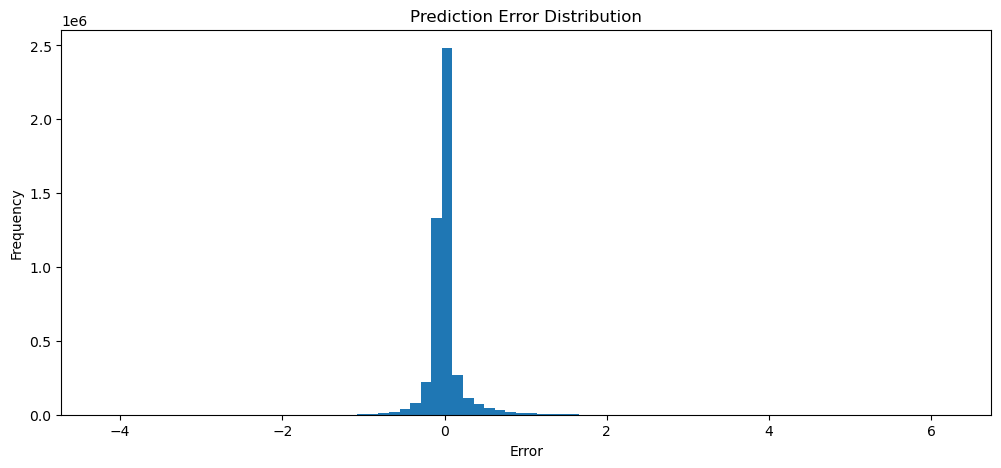

In [28]:
# Modelin tahmin hatalarının dağılımını histogram olarak gösterimi

plt.figure(figsize=(12,5))

plt.hist(
    lightgbm_prediction_df["Error"],
    bins=80
)

plt.title("Prediction Error Distribution")

plt.xlabel("Error")

plt.ylabel("Frequency")

plt.show()

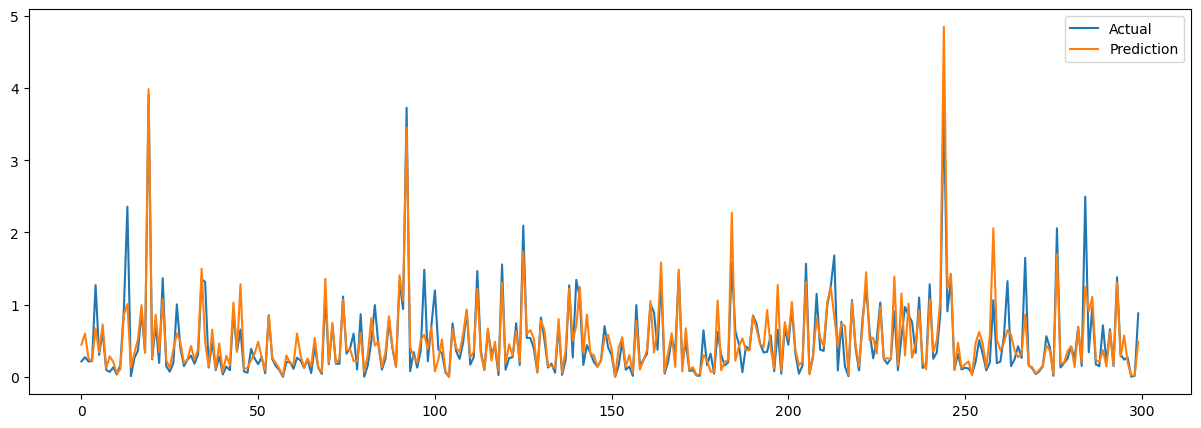

In [29]:
# Prediction-Actual Grafik, 
# Test veri setindeki ilk 300 gerçek değer ile model tahminlerinin çizgi grafik ile gösterimi

plt.figure(figsize=(15,5))

plt.plot(
    y_test.values[:300],
    label="Actual"
)

plt.plot(
    lightgbm_predictions[:300],
    label="Prediction"
)

plt.legend()

plt.show()

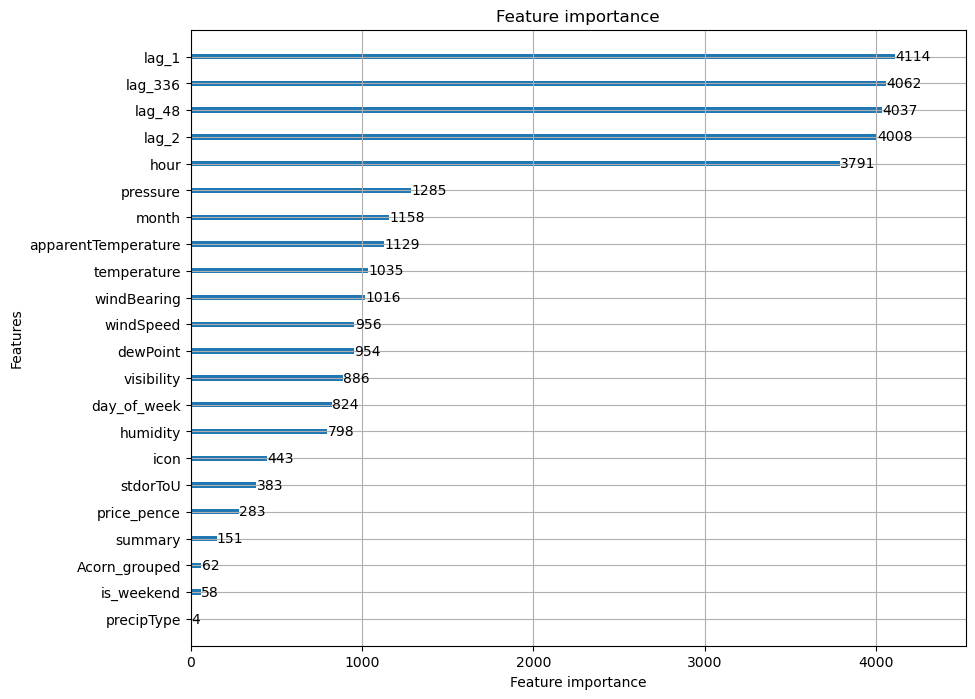

In [30]:
# Feature Importance 

import lightgbm as lgb

lgb.plot_importance(
    lightgbm_model,
    figsize=(10,8)
)

plt.show()

In [ ]:
# ======================================================
# Part 4
# XGBoost Model and Evaluation
# ======================================================

In [31]:
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [32]:
# XGBoost için veri kopyalarını oluşturuyoruz

X_train_xgb = pd.get_dummies(
    X_train,
    columns=categorical_columns,
    drop_first=False,
    dtype=np.uint8
)

X_validation_xgb = pd.get_dummies(
    X_validation,
    columns=categorical_columns,
    drop_first=False,
    dtype=np.uint8
)

X_test_xgb = pd.get_dummies(
    X_test,
    columns=categorical_columns,
    drop_first=False,
    dtype=np.uint8
)

In [33]:
# Train, validation ve test setlerinde aynı sütunların bulunması gerekli

X_validation_xgb = X_validation_xgb.reindex(
    columns=X_train_xgb.columns,
    fill_value=0
)

X_test_xgb = X_test_xgb.reindex(
    columns=X_train_xgb.columns,
    fill_value=0
)

print("X_train_xgb shape      :", X_train_xgb.shape)
print("X_validation_xgb shape :", X_validation_xgb.shape)
print("X_test_xgb shape       :", X_test_xgb.shape)

print(
    "Validation columns match:",
    X_train_xgb.columns.equals(
        X_validation_xgb.columns
    )
)

print(
    "Test columns match:",
    X_train_xgb.columns.equals(
        X_test_xgb.columns
    )
)

X_train_xgb shape      : (22256924, 44)
X_validation_xgb shape : (4769436, 44)
X_test_xgb shape       : (4769743, 44)
Validation columns match: True
Test columns match: True


In [34]:
# Model

xgboost_model = XGBRegressor(
    
    objective="reg:squarederror",
    
    learning_rate=0.05,  # ideal olduğunu düşündüğüm learning rate, 0.3 hızlı ama hata olur, 0.01 çok yavaş
    
    n_estimators=1000, # kaç tane ağaç oluşacak
    
    max_depth=8,
    
    min_child_weight=1,
    
    subsample=0.8,
    
    colsample_bytree=0.8,
    
    reg_alpha=0.0,
    
    reg_lambda=1.0,
    
    early_stopping_rounds=50,
    
    eval_metric="rmse",
    
    random_state=RANDOM_STATE,
    
    n_jobs=-1
)

In [35]:
# Train 

start = time.time()

xgboost_model.fit(
    X_train_xgb,
    y_train,
    eval_set=[
        (X_validation_xgb, y_validation)
    ],
    verbose=50
)

xgboost_training_time = time.time() - start

print(
    f"Training Time: "
    f"{xgboost_training_time:.2f} seconds"
)

print(
    "Best iteration:",
    xgboost_model.best_iteration
)

[0]	validation_0-rmse:0.30320
[50]	validation_0-rmse:0.17385
[100]	validation_0-rmse:0.17179
[150]	validation_0-rmse:0.17160
[200]	validation_0-rmse:0.17152
[250]	validation_0-rmse:0.17147
[300]	validation_0-rmse:0.17142
[350]	validation_0-rmse:0.17137
[400]	validation_0-rmse:0.17135
[450]	validation_0-rmse:0.17133
[500]	validation_0-rmse:0.17132
[547]	validation_0-rmse:0.17132
Training Time: 1476.75 seconds
Best iteration: 497


In [36]:
# Test

xgboost_predictions = xgboost_model.predict(
    X_test_xgb
)

# Negatif tüketim tahminlerini engelliyoruz

xgboost_predictions = np.clip(
    xgboost_predictions,
    0,
    None
)

In [37]:
# MAE

xgboost_mae = mean_absolute_error(
    y_test,
    xgboost_predictions
)

print(f"MAE  : {xgboost_mae:.4f}")

MAE  : 0.1019


In [38]:
# RMSE

xgboost_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgboost_predictions
    )
)

print(f"RMSE : {xgboost_rmse:.4f}")

RMSE : 0.2051


In [39]:
# R^2 Score

xgboost_r2 = r2_score(
    y_test,
    xgboost_predictions
)

print(f"R²   : {xgboost_r2:.4f}")

R²   : 0.7492


In [40]:
# Sonuç Tablosu

xgboost_results = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R2 Score"
    ],
    "Value": [
        xgboost_mae,
        xgboost_rmse,
        xgboost_r2
    ]
})

display(xgboost_results)

,Metric,Value
0,MAE,0.101876
1,RMSE,0.205068
2,R2 Score,0.749179


In [41]:
# Gerçek değerlerle modelin tahminlerini karşılaştıran tablo

prediction_df2 = pd.DataFrame({
    "Actual": y_test.values,
    "Prediction": xgboost_predictions
})

In [42]:
# Her tahmin için gerçek değer ile tahmin arasındaki farkım hesaplanması

prediction_df2["Error"] = (
    prediction_df2["Actual"]
    - prediction_df2["Prediction"]
)

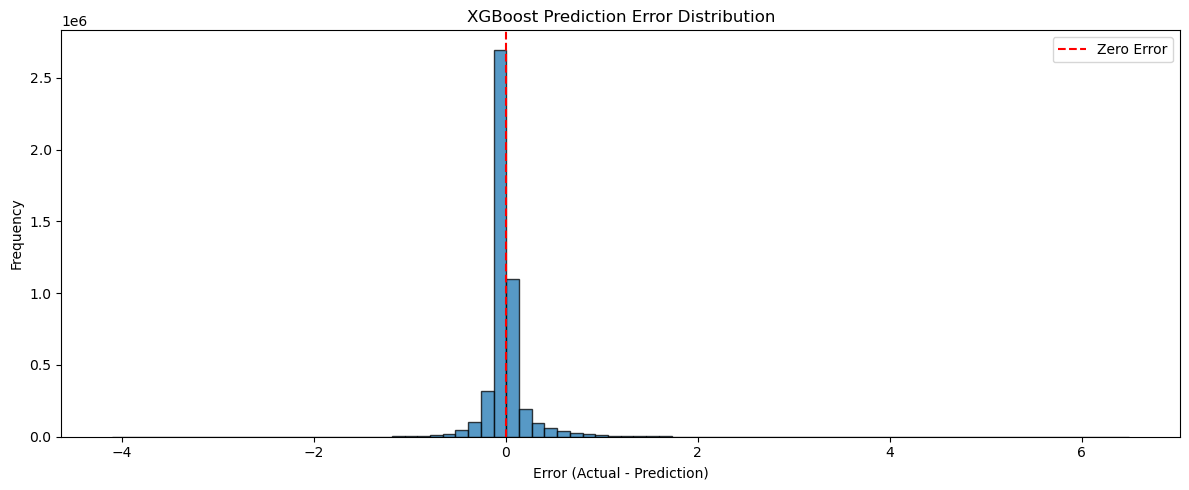

In [43]:
# Modelin tahmin hatalarının dağılımını histogram olarak gösterimi

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.hist(
    prediction_df2["Error"],
    bins=80,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    0,
    color="red",
    linestyle="--",
    label="Zero Error"
)

plt.title("XGBoost Prediction Error Distribution")
plt.xlabel("Error (Actual - Prediction)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

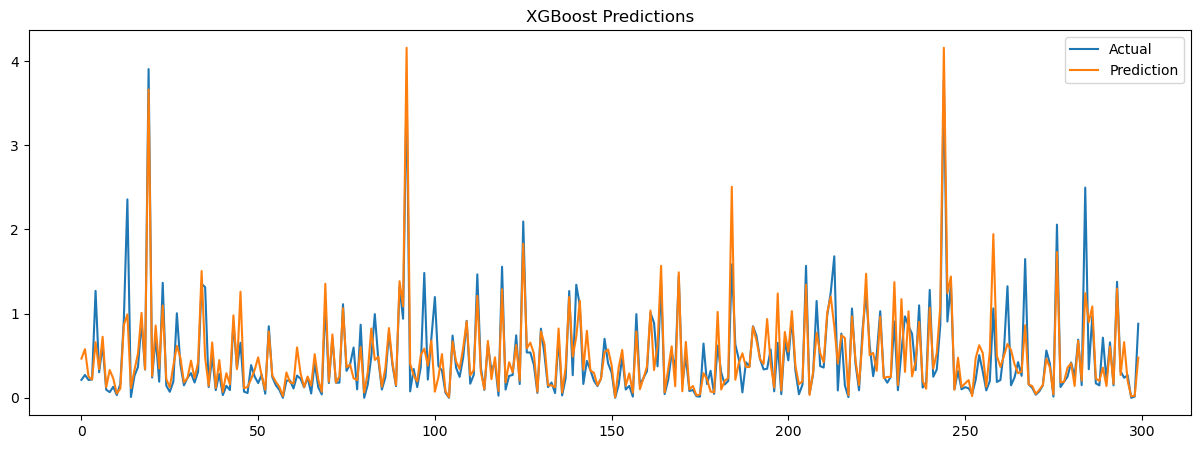

In [44]:
# XGBoost modelinin ilk 300 tahminini gerçek değerlerle karşılaştıran çizgi grafik

plt.figure(figsize=(15,5))

plt.plot(
    y_test.values[:300],
    label="Actual"
)

plt.plot(
    xgboost_predictions[:300],
    label="Prediction"
)

plt.title("XGBoost Predictions")

plt.legend()

plt.show()

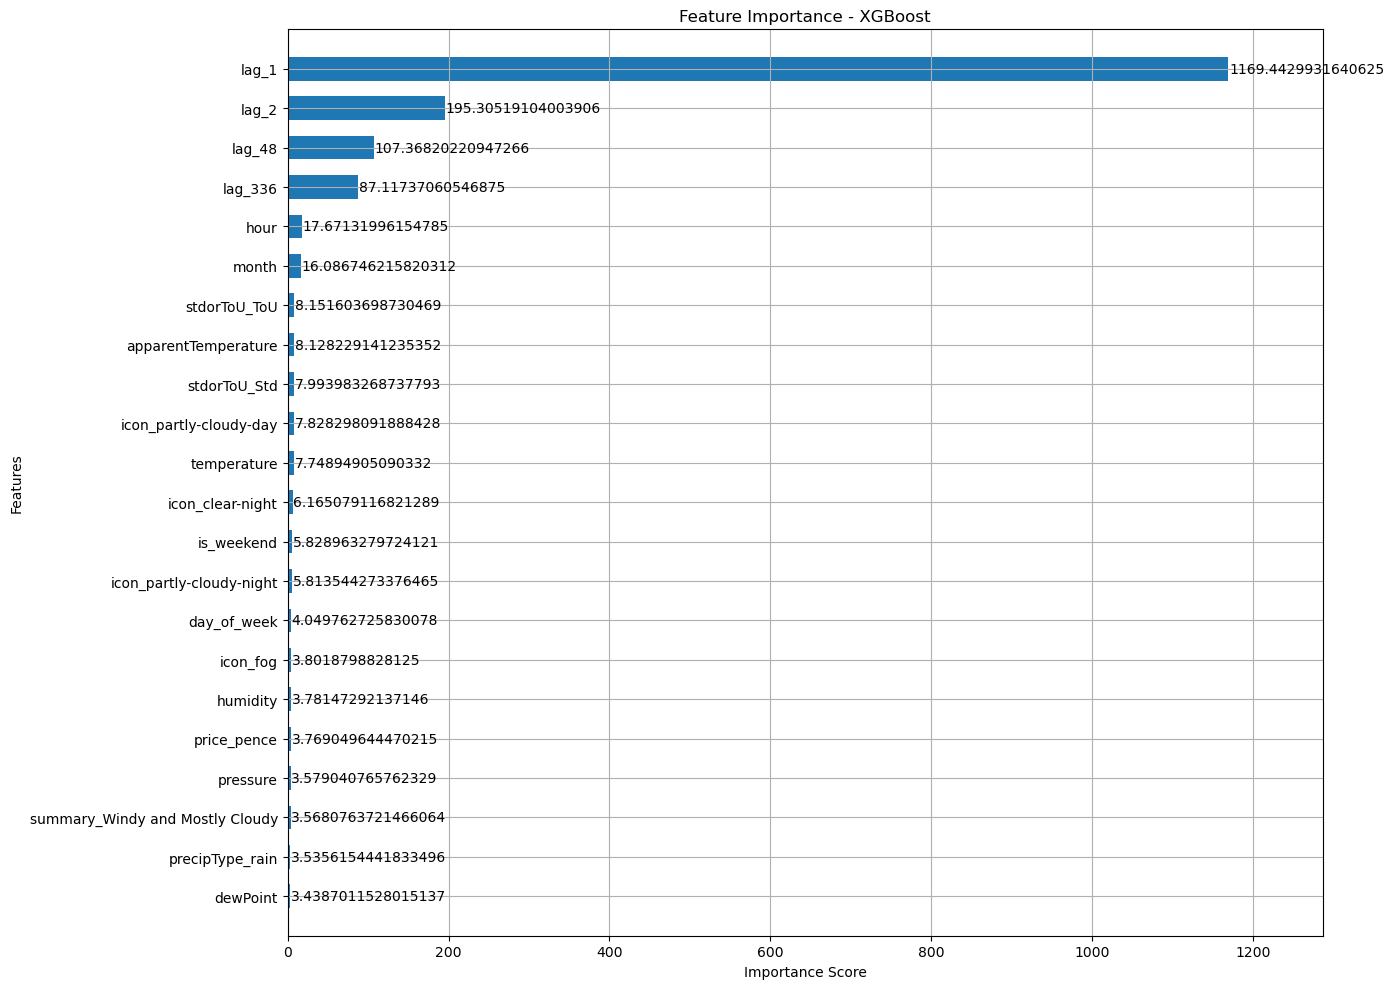

In [45]:
# Feature Importance

import matplotlib.pyplot as plt
from xgboost import plot_importance

fig, ax = plt.subplots(figsize=(14, 10))

plot_importance(
    xgboost_model,
    ax=ax,
    max_num_features=22,
    importance_type="gain",
    height=0.6,
    show_values=True
)

plt.title("Feature Importance - XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [ ]:
# ======================================================
# Part 5
# LightGBM Model and XGBoost Model Comparison
# ======================================================

In [46]:
# Model Karşılaştırma Tablosu

model_comparison = pd.DataFrame({
    "Model": [
        "LightGBM",
        "XGBoost"
    ],
    "MAE": [
        lightgbm_mae,
        xgboost_mae
    ],
    "RMSE": [
        lightgbm_rmse,
        xgboost_rmse
    ],
    "R2 Score": [
        lightgbm_r2,
        xgboost_r2
    ],
    "Training Time (seconds)": [
        lightgbm_training_time,
        xgboost_training_time
    ]
})

model_comparison = model_comparison.sort_values(
    by="RMSE"
).reset_index(drop=True)

display(model_comparison)

,Model,MAE,RMSE,R2 Score,Training Time (seconds)
0,LightGBM,0.102158,0.204614,0.750289,265.327065
1,XGBoost,0.101876,0.205068,0.749179,1476.754925


In [47]:
# En iyi model seçimi

best_model_row = model_comparison.iloc[0]

print(f"Best Model : {best_model_row['Model']}")
print(f"MAE        : {best_model_row['MAE']:.4f}")
print(f"RMSE       : {best_model_row['RMSE']:.4f}")
print(f"R²         : {best_model_row['R2 Score']:.4f}")
print(
    f"Training Time: "
    f"{best_model_row['Training Time (seconds)']:.2f} seconds"
)

# Model seçerken yalnızca en küçük RMSE değerine bakmayacağız. 
# Performans farkı çok küçükse daha hızlı ve daha sade olan LightGBM’yi seçeceğiz.

Best Model : LightGBM
MAE        : 0.1022
RMSE       : 0.2046
R²         : 0.7503
Training Time: 265.33 seconds


In [ ]:
# ======================================================
# Part 6
# Residual-Based Anomaly Detection
# ======================================================

In [48]:
# En iyi modelin tahminlerinin seçimi

best_model_name = model_comparison.iloc[0]["Model"]

if best_model_name == "LightGBM":

    selected_model = lightgbm_model

    validation_predictions = selected_model.predict(
        X_validation,
        num_iteration=selected_model.best_iteration_
    )

    test_predictions = lightgbm_predictions

elif best_model_name == "XGBoost":

    selected_model = xgboost_model

    validation_predictions = selected_model.predict(
        X_validation_xgb
    )

    test_predictions = xgboost_predictions

else:
    raise ValueError("Unknown model type")

validation_predictions = np.clip(
    validation_predictions,
    0,
    None
)

test_predictions = np.clip(
    test_predictions,
    0,
    None
)

print("Selected model:", best_model_name)

Selected model: LightGBM


In [49]:
# Validation residual'larından Anomali eşiğini öğrenme

validation_residuals = (
    y_validation.to_numpy()
    - validation_predictions
)

# Beklenmedik yüksek tüketimler için pozitif residual
anomaly_threshold = np.quantile(
    validation_residuals,
    0.99
)

print(
    f"Anomaly threshold: "
    f"{anomaly_threshold:.4f} kWh"
)

Anomaly threshold: 0.7039 kWh


In [50]:
# Test dönemindeki anomalileri belirleme

anomaly_results = test_df[
    [
        "LCLid",
        "tstp",
        "energy(kWh/hh)",
        "price_pence"
    ]
].copy()

anomaly_results["predicted_kwh"] = (
    test_predictions
)

anomaly_results["residual"] = (
    anomaly_results["energy(kWh/hh)"]
    - anomaly_results["predicted_kwh"]
)

anomaly_results["is_anomaly"] = (
    anomaly_results["residual"]
    > anomaly_threshold
)

anomaly_results["anomaly_score"] = (
    anomaly_results["residual"]
    / anomaly_threshold
)

In [51]:
# Önem seviyesi ekleme

conditions = [
    anomaly_results["anomaly_score"] >= 3,
    anomaly_results["anomaly_score"] >= 2,
    anomaly_results["anomaly_score"] >= 1
]

choices = [
    "high",
    "medium",
    "low"
]

anomaly_results["severity"] = np.select(
    conditions,
    choices,
    default="normal"
)

In [52]:
# Anomaly Özeti

detected_anomalies = (
    anomaly_results[
        anomaly_results["is_anomaly"]
    ]
    .sort_values(
        "anomaly_score",
        ascending=False
    )
)

print(
    f"Test records       : "
    f"{len(anomaly_results):,}"
)

print(
    f"Detected anomalies : "
    f"{len(detected_anomalies):,}"
)

print(
    f"Anomaly percentage : "
    f"{anomaly_results['is_anomaly'].mean() * 100:.2f}%"
)

display(
    detected_anomalies.head(20)
)

Test records       : 4,769,743
Detected anomalies : 67,345
Anomaly percentage : 1.41%


,LCLid,tstp,energy(kWh/hh),price_pence,predicted_kwh,residual,is_anomaly,anomaly_score,severity
28684989,MAC005406,2013-12-20 20:30:00,9.001,14.228,2.783170,6.217830,True,8.834007,high
28684040,MAC005406,2013-12-20 20:00:00,8.998,14.228,2.861284,6.136716,True,8.718764,high
28683091,MAC005406,2013-12-20 19:30:00,9.141,14.228,3.426911,5.714089,True,8.118314,high
31205555,MAC000320,2014-02-14 18:00:00,6.147,14.228,1.037403,5.109597,True,7.259480,high
31603834,MAC000320,2014-02-23 16:30:00,4.941,14.228,0.133275,4.807725,True,6.830594,high
28685938,MAC005406,2013-12-20 21:00:00,7.470,14.228,2.663606,4.806394,True,6.828703,high
31609322,MAC005521,2014-02-23 19:00:00,5.018,14.228,0.277233,4.740767,True,6.735463,high
29221637,MAC005521,2014-01-01 15:30:00,5.049,14.228,0.333417,4.715583,True,6.699683,high
29560846,MAC002644,2014-01-09 03:00:00,5.054,14.228,0.353637,4.700363,True,6.678059,high
31125820,MAC002644,2014-02-12 23:00:00,5.920,14.228,1.243342,4.676658,True,6.644381,high


In [ ]:
# ======================================================
# Part 7
# Model Export
# ======================================================

In [53]:
from pathlib import Path
from datetime import datetime, timezone

import json
import joblib

In [54]:
# Artifact klasörü ve metadata oluşturma

ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

category_levels = {
    column: X_train[column].cat.categories.tolist()
    for column in categorical_columns
}

model_metadata = {
    "schema_version": "1.0",
    "model_type": best_model_name,
    "target_column": target_column,
    "feature_columns": list(X_train.columns),
    "categorical_columns": categorical_columns,
    "category_levels": category_levels,
    "anomaly_threshold": float(anomaly_threshold),
    "best_iteration": int(
        lightgbm_model.best_iteration_
    ),
    "interval_minutes": 30,
    "metrics": {
        "mae": float(lightgbm_mae),
        "rmse": float(lightgbm_rmse),
        "r2": float(lightgbm_r2)
    },
    "train_period": {
        "start": str(train_df["tstp"].min()),
        "end": str(train_df["tstp"].max())
    },
    "validation_period": {
        "start": str(validation_df["tstp"].min()),
        "end": str(validation_df["tstp"].max())
    },
    "test_period": {
        "start": str(test_df["tstp"].min()),
        "end": str(test_df["tstp"].max())
    },
    "created_at": datetime.now(
        timezone.utc
    ).isoformat()
}

In [55]:
# Model ve metadata’yı tek dosyaya kaydet

model_bundle = {
    "model": selected_model,
    "metadata": model_metadata
}

bundle_path = (
    ARTIFACT_DIR /
    "energy_forecast_bundle.joblib"
)

joblib.dump(
    model_bundle,
    bundle_path
)

print(
    f"Model bundle saved: "
    f"{bundle_path.resolve()}"
)

Model bundle saved: C:\Users\yasem\Desktop\volti\artifacts\energy_forecast_bundle.joblib


In [56]:
# Okunabilir Metadata dosyası

metadata_path = (
    ARTIFACT_DIR /
    "energy_forecast_metadata.json"
)

with open(
    metadata_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        model_metadata,
        file,
        ensure_ascii=False,
        indent=2
    )

print(
    f"Metadata saved: "
    f"{metadata_path.resolve()}"
)

Metadata saved: C:\Users\yasem\Desktop\volti\artifacts\energy_forecast_metadata.json


In [57]:
# Export test

loaded_bundle = joblib.load(
    bundle_path
)

loaded_model = loaded_bundle["model"]
loaded_metadata = loaded_bundle["metadata"]

export_test_predictions = loaded_model.predict(
    X_test.head(10),
    num_iteration=loaded_metadata[
        "best_iteration"
    ]
)

original_test_predictions = (
    lightgbm_predictions[:10]
)

export_is_valid = np.allclose(
    export_test_predictions,
    original_test_predictions
)

print(
    "Export validation:",
    export_is_valid
)

Export validation: True
